## ADLD

## Preprocess
<!-- `curl -L -o a-dual-labeled-dataset.zip https://www.kaggle.com/api/v1/datasets/download/zwbzwb12341234/a-dual-labeled-dataset` -->


In [ ]:
import cv2
import numpy as np
import os
import random
import json
import matplotlib.pyplot as plt

# Directories containing images and labels
image_dir = "adld/images"
label_dir = "adld/labels"

# Select one random image file
all_images = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_file = random.choice(all_images)
print("Selected image file:", image_file)

# Build paths to the image and corresponding JSON label
image_path = os.path.join(image_dir, image_file)
json_file_path = os.path.join(label_dir, os.path.splitext(image_file)[0] + ".json")

# Load the image
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

# Load ground truth annotations from the JSON file
with open(json_file_path, 'r') as f:
    data = json.load(f)

# Create an empty mask for the ground truth segmentation
ground_truth_mask = np.zeros_like(image, dtype=np.uint8)

# Loop through each annotated shape
for shape in data.get("shapes", []):
    points = np.array(shape["points"], dtype=np.int32)
    label = shape.get("label", "N/A")  # Get the label or default to "N/A"

    # Fill each shape with a random color
    color = np.random.randint(0, 255, 3, dtype=np.uint8)
    cv2.fillPoly(ground_truth_mask, [points], color=color.tolist())

    # Create a mask to extract contours
    temp_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.fillPoly(temp_mask, [points], 1)
    contours, _ = cv2.findContours(temp_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw contours in red
    cv2.drawContours(ground_truth_mask, contours, -1, (255, 0, 0), 3)
    
    # Calculate centroid for label placement
    M = cv2.moments(points)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        # Use first point if centroid calculation fails
        cX, cY = points[0][0], points[0][1]
    
    # Put the label text near the centroid
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.0
    thickness = 2
    text_size = cv2.getTextSize(label, font, font_scale, thickness)[0]
    
    # Adjust text position to ensure it's within the image bounds
    text_x = max(0, min(cX - text_size[0] // 2, image.shape[1] - text_size[0]))
    text_y = max(text_size[1], min(cY + text_size[1] // 2, image.shape[0]))
    
    # Draw white text with black background for better visibility
    cv2.putText(ground_truth_mask, label, (text_x, text_y), 
                font, font_scale, (0, 0, 0), thickness + 2, cv2.LINE_AA)
    cv2.putText(ground_truth_mask, label, (text_x, text_y), 
                font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

# Blend the original image and the mask
combined_image = cv2.addWeighted(image, 0.6, ground_truth_mask, 0.4, 0)

# Convert BGR to RGB for displaying via matplotlib
combined_image_rgb = cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB)

# Show the result using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(combined_image_rgb)
plt.title("Combined Image with Ground Truth Annotations")
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np
import os
import json
from tqdm import tqdm
import shutil
import random
import matplotlib.pyplot as plt

# =============================================
# Processing Code (Code 1) - FIXED
# =============================================

# Directories
image_dir = "adld/images"
label_dir = "adld/labels"
output_dir = "adld_cropped"
output_dir_images = os.path.join(output_dir, "images")
output_dir_labels = os.path.join(output_dir, "labels")
output_dir_masks = os.path.join(output_dir, "masks")
output_dir_visuals = os.path.join(output_dir, "visualizations")  # New directory for visualizations

# Create output directories
os.makedirs(output_dir_images, exist_ok=True)
os.makedirs(output_dir_labels, exist_ok=True)
os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_visuals, exist_ok=True)

# Target sizes
target_height, target_width = 512, 1024
target_size_cropped = (256, 256)

# Padding
padding = 10
corner_padding = 60

# Label mapping (background=0, both teeth=1)
label_map = {"38": 1, "48": 1}

def create_mask_from_json(json_data, image_size, current_label):
    """Create mask at original image size"""
    mask = np.zeros(image_size[:2], dtype=np.uint8)
    for shape in json_data.get("shapes", []):
        if shape.get("label") == current_label:
            points = np.array(shape["points"], dtype=np.int32)
            cv2.fillPoly(mask, [points], color=255)
    return mask

def update_json_data(original_data, crop_coords, current_label, flip=False, target_size=(256, 256)):
    x_min, y_min, x_max, y_max = crop_coords
    cropped_width = x_max - x_min
    cropped_height = y_max - y_min
    
    new_data = {
        "version": original_data.get("version", ""),
        "flags": original_data.get("flags", {}),
        "shapes": [],
        "imagePath": original_data["imagePath"],
        "imageData": None,
        "imageHeight": target_size[1],
        "imageWidth": target_size[0],
        "label_map": {"background": 0, "tooth": 1}
    }
    
    for shape in original_data.get("shapes", []):
        if shape.get("label") != current_label:
            continue
            
        points = np.array(shape["points"], dtype=np.float32)
        points[:, 0] = points[:, 0] * (target_width / original_data["imageWidth"])
        points[:, 1] = points[:, 1] * (target_height / original_data["imageHeight"])
        points[:, 0] = points[:, 0] - x_min
        points[:, 1] = points[:, 1] - y_min
        
        if flip:
            points[:, 0] = cropped_width - points[:, 0]
        
        points[:, 0] = points[:, 0] * (target_size[0] / cropped_width)
        points[:, 1] = points[:, 1] * (target_size[1] / cropped_height)
        
        new_shape = {
            "label": "1",
            "points": points.tolist(),
            "group_id": shape.get("group_id", None),
            "shape_type": shape["shape_type"],
            "flags": shape.get("flags", {})
        }
        new_data["shapes"].append(new_shape)
    
    return new_data

def create_visualization(image_path, json_path, mask_path, output_path):
    """Create visualization comparing image+labels and image+mask"""
    # Load all components
    image = cv2.imread(image_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Create label visualization (left panel)
    label_vis = image.copy()
    for shape in data.get("shapes", []):
        points = np.array(shape["points"], dtype=np.int32)
        color = (0, 255, 0)  # Green for labels
        cv2.fillPoly(label_vis, [points], color=color)
        
        # Draw contours
        temp_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        cv2.fillPoly(temp_mask, [points], 1)
        contours, _ = cv2.findContours(temp_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(label_vis, contours, -1, (0, 0, 255), 2)  # Red contours
    
    # Create mask visualization (right panel)
    mask_vis = image.copy()
    mask_vis[mask == 255] = (0, 255, 0)  # Highlight mask areas in green
    
    # Combine both visualizations
    combined = np.hstack([label_vis, mask_vis])
    
    # Add titles
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(combined, "Image + Labels", (10, 30), font, 0.8, (255, 255, 255), 2)
    cv2.putText(combined, "Image + Mask", (image.shape[1] + 10, 30), font, 0.8, (255, 255, 255), 2)
    
    # Save visualization
    cv2.imwrite(output_path, combined)

# Process each image
all_images = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

for image_file in tqdm(all_images, desc="Processing images"):
    image_path = os.path.join(image_dir, image_file)
    json_path = os.path.join(label_dir, os.path.splitext(image_file)[0] + ".json")
    
    if not os.path.exists(json_path):
        continue
    
    # Load original image and get size
    image = cv2.imread(image_path)
    if image is None:
        continue
    orig_height, orig_width = image.shape[:2]
    
    # Load JSON data
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Resize image to target size
    resized_image = cv2.resize(image, (target_width, target_height), interpolation=cv2.INTER_AREA)
    
    filename_base = os.path.splitext(image_file)[0]
    
    for shape in data.get("shapes", []):
        label = shape.get("label", "N/A")
        
        if label in ["38", "48"]:
            # Create mask specifically for this label/shape
            original_mask = create_mask_from_json(data, (orig_height, orig_width), label)
            resized_mask = cv2.resize(original_mask, (target_width, target_height), interpolation=cv2.INTER_NEAREST)
            
            points = np.array(shape["points"], dtype=np.float32)
            points[:, 0] *= (target_width / orig_width)
            points[:, 1] *= (target_height / orig_height)
            points = points.astype(np.int32)
            
            x_min, y_min = np.min(points, axis=0)
            x_max, y_max = np.max(points, axis=0)
            
            # Apply padding
            x_min = max(0, x_min - padding)
            y_min = max(0, y_min - padding)
            x_max = min(target_width, x_max + padding)
            y_max = min(target_height, y_max + padding)
            
            flip = False
            if label == "38":
                x_max = min(target_width, x_max + corner_padding)
                y_max = min(target_height, y_max + corner_padding)
                output_filename = f"{filename_base}_{label}"
            elif label == "48":
                x_min = max(0, x_min - corner_padding)
                y_max = min(target_height, y_max + corner_padding)
                output_filename = f"{filename_base}_{label}_flipped"
                flip = True
            
            # Crop and process both image and mask
            cropped_image = resized_image[y_min:y_max, x_min:x_max]
            cropped_mask = resized_mask[y_min:y_max, x_min:x_max]
            
            if flip:
                cropped_image = cv2.flip(cropped_image, 1)
                cropped_mask = cv2.flip(cropped_mask, 1)
            
            # Resize to final target size
            final_image = cv2.resize(cropped_image, target_size_cropped, interpolation=cv2.INTER_AREA)
            final_mask = cv2.resize(cropped_mask, target_size_cropped, interpolation=cv2.INTER_NEAREST)
            
            # Save results
            image_output_path = os.path.join(output_dir_images, f"{output_filename}.png")
            mask_output_path = os.path.join(output_dir_masks, f"{output_filename}.png")
            json_output_path = os.path.join(output_dir_labels, f"{output_filename}.json")
            vis_output_path = os.path.join(output_dir_visuals, f"{output_filename}_vis.png")
            
            cv2.imwrite(image_output_path, final_image)
            cv2.imwrite(mask_output_path, final_mask)
            
            # Save JSON
            updated_data = update_json_data(data, (x_min, y_min, x_max, y_max), label, flip)
            with open(json_output_path, 'w') as f:
                json.dump(updated_data, f, indent=2)
            
            # Create and save visualization
            create_visualization(image_output_path, json_output_path, mask_output_path, vis_output_path)

print(f"Processing complete. Results saved to: {output_dir}")
print(f"- Images: {output_dir_images}")
print(f"- Masks: {output_dir_masks}")
print(f"- JSONs: {output_dir_labels}")
print(f"- Visualizations: {output_dir_visuals}")

# =============================================
# Visualization Code (Code 2 - Modified)
# =============================================

def show_random_visualization(visual_dir):
    """Display a random visualization from the output directory"""
    all_visuals = [f for f in os.listdir(visual_dir) if f.lower().endswith('.png')]
    if not all_visuals:
        print("No visualizations found!")
        return
    
    vis_file = random.choice(all_visuals)
    vis_path = os.path.join(visual_dir, vis_file)
    
    vis_image = cv2.imread(vis_path)
    vis_image = cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(vis_image)
    plt.title(f"Visualization: {vis_file}")
    plt.axis('off')
    plt.show()

# Show a random visualization
show_random_visualization(output_dir_visuals)

In [ ]:
show_random_visualization(output_dir_visuals)

In [ ]:
import cv2
import numpy as np
import os
import json
import yaml
from tqdm import tqdm
import shutil
import random
from sklearn.model_selection import train_test_split

# =============================================
# ADLD to YOLOv8 Format Conversion
# =============================================

def convert_adld_to_yolo():
    """Convert ADLD cropped dataset to YOLOv8 segmentation format"""
    
    # Source directories
    source_dir = "adld_cropped"
    source_images = os.path.join(source_dir, "images")
    source_labels = os.path.join(source_dir, "labels")
    source_masks = os.path.join(source_dir, "masks")
    
    # Output directory
    output_dir = "adld_yolo8"
    
    # Create YOLOv8 directory structure
    train_images_dir = os.path.join(output_dir, "images", "train")
    val_images_dir = os.path.join(output_dir, "images", "val")
    train_labels_dir = os.path.join(output_dir, "labels", "train")
    val_labels_dir = os.path.join(output_dir, "labels", "val")
    
    os.makedirs(train_images_dir, exist_ok=True)
    os.makedirs(val_images_dir, exist_ok=True)
    os.makedirs(train_labels_dir, exist_ok=True)
    os.makedirs(val_labels_dir, exist_ok=True)
    
    print(f"Created YOLOv8 directory structure at: {output_dir}")
    
    def polygon_to_yolo_segmentation(points, img_width, img_height):
        """Convert polygon points to YOLO segmentation format (normalized coordinates)"""
        normalized_points = []
        for point in points:
            x, y = point
            # Normalize coordinates to [0, 1]
            norm_x = x / img_width
            norm_y = y / img_height
            # Clamp to [0, 1] to avoid any boundary issues
            norm_x = max(0, min(1, norm_x))
            norm_y = max(0, min(1, norm_y))
            normalized_points.extend([norm_x, norm_y])
        return normalized_points
    
    def process_json_to_yolo_label(json_path, image_path):
        """Convert JSON annotation to YOLO format"""
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Get image dimensions
        image = cv2.imread(image_path)
        img_height, img_width = image.shape[:2]
        
        yolo_annotations = []
        
        # Process each shape (should be only one tooth per image in this dataset)
        for shape in data.get("shapes", []):
            if shape.get("label") == "1":  # Tooth class
                points = shape["points"]
                
                # Convert to YOLO segmentation format
                yolo_coords = polygon_to_yolo_segmentation(points, img_width, img_height)
                
                # Class 0 for tooth (YOLOv8 uses 0-based indexing)
                class_id = 0
                
                # Format: class_id x1 y1 x2 y2 ... xn yn
                yolo_line = f"{class_id} " + " ".join([f"{coord:.6f}" for coord in yolo_coords])
                yolo_annotations.append(yolo_line)
        
        return yolo_annotations
    
    # Get all image files
    all_images = [f for f in os.listdir(source_images) if f.lower().endswith('.png')]
    print(f"Found {len(all_images)} images to process")
    
    # Split into train/val (80/20 split)
    train_files, val_files = train_test_split(all_images, test_size=0.2, random_state=42)
    
    print(f"Train set: {len(train_files)} images")
    print(f"Validation set: {len(val_files)} images")
    
    def process_split(file_list, images_dir, labels_dir, split_name):
        """Process files for a specific split (train/val)"""
        processed_count = 0
        
        for image_file in tqdm(file_list, desc=f"Processing {split_name} set"):
            # Source paths
            image_path = os.path.join(source_images, image_file)
            json_file = os.path.splitext(image_file)[0] + ".json"
            json_path = os.path.join(source_labels, json_file)
            
            # Skip if JSON doesn't exist
            if not os.path.exists(json_path):
                print(f"Warning: No JSON found for {image_file}")
                continue
            
            # Destination paths
            dest_image_path = os.path.join(images_dir, image_file)
            dest_label_path = os.path.join(labels_dir, os.path.splitext(image_file)[0] + ".txt")
            
            try:
                # Copy image
                shutil.copy2(image_path, dest_image_path)
                
                # Convert and save label
                yolo_annotations = process_json_to_yolo_label(json_path, image_path)
                
                with open(dest_label_path, 'w') as f:
                    f.write("\n".join(yolo_annotations))
                
                processed_count += 1
                
            except Exception as e:
                print(f"Error processing {image_file}: {e}")
                continue
        
        return processed_count
    
    # Process train and validation splits
    train_processed = process_split(train_files, train_images_dir, train_labels_dir, "train")
    val_processed = process_split(val_files, val_images_dir, val_labels_dir, "validation")
    
    # Create data.yaml configuration file
    data_yaml = {
        'path': os.path.abspath(output_dir),
        'train': 'images/train',
        'val': 'images/val',
        'nc': 1,  # number of classes
        'names': ['tooth']  # class names
    }
    
    yaml_path = os.path.join(output_dir, "data.yaml")
    with open(yaml_path, 'w') as f:
        yaml.dump(data_yaml, f, default_flow_style=False)
    
    print(f"\n=== Conversion Complete ===")
    print(f"Output directory: {output_dir}")
    print(f"Train images processed: {train_processed}")
    print(f"Validation images processed: {val_processed}")
    print(f"Total processed: {train_processed + val_processed}")
    print(f"Configuration file: {yaml_path}")
    print(f"\nDataset structure:")
    print(f"├── images/")
    print(f"│   ├── train/ ({train_processed} images)")
    print(f"│   └── val/ ({val_processed} images)")
    print(f"├── labels/")
    print(f"│   ├── train/ ({train_processed} labels)")
    print(f"│   └── val/ ({val_processed} labels)")
    print(f"└── data.yaml")
    
    return output_dir

# Run the conversion
output_directory = convert_adld_to_yolo()

# =============================================
# Validation and Sample Display
# =============================================

def validate_yolo_conversion(yolo_dir, num_samples=3):
    """Validate the YOLO conversion by displaying some samples"""
    
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from matplotlib.patches import Polygon
    
    train_images_dir = os.path.join(yolo_dir, "images", "train")
    train_labels_dir = os.path.join(yolo_dir, "labels", "train")
    
    # Get some random samples
    all_images = [f for f in os.listdir(train_images_dir) if f.lower().endswith('.png')]
    sample_images = random.sample(all_images, min(num_samples, len(all_images)))
    
    fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 5))
    if len(sample_images) == 1:
        axes = [axes]
    
    for idx, image_file in enumerate(sample_images):
        # Load image
        image_path = os.path.join(train_images_dir, image_file)
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_height, img_width = image.shape[:2]
        
        # Load corresponding label
        label_file = os.path.splitext(image_file)[0] + ".txt"
        label_path = os.path.join(train_labels_dir, label_file)
        
        ax = axes[idx]
        ax.imshow(image_rgb)
        ax.set_title(f"Sample: {image_file}")
        ax.axis('off')
        
        # Draw annotations if label file exists
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 7:  # At least class + 3 points
                    class_id = int(parts[0])
                    coords = [float(x) for x in parts[1:]]
                    
                    # Convert normalized coordinates back to pixel coordinates
                    pixel_coords = []
                    for i in range(0, len(coords), 2):
                        x = coords[i] * img_width
                        y = coords[i+1] * img_height
                        pixel_coords.append([x, y])
                    
                    # Draw polygon
                    polygon = Polygon(pixel_coords, linewidth=2, edgecolor='red', 
                                    facecolor='none', alpha=0.7)
                    ax.add_patch(polygon)
                    
                    # Add class label
                    if pixel_coords:
                        centroid_x = sum([p[0] for p in pixel_coords]) / len(pixel_coords)
                        centroid_y = sum([p[1] for p in pixel_coords]) / len(pixel_coords)
                        ax.text(centroid_x, centroid_y, f'tooth', 
                               bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                               fontsize=8, ha='center')
    
    plt.tight_layout()
    plt.savefig(os.path.join(yolo_dir, "sample_validation.png"))
    plt.show()
    
    
    print(f"Validation complete. Displayed {len(sample_images)} sample annotations.")

# Validate the conversion
validate_yolo_conversion(output_directory)

print("\n" + "="*50)
print("YOLO v8 Dataset Conversion Complete!")
print("="*50)
print(f"You can now use this dataset for YOLOv8 training with:")
print(f"yolo task=segment mode=train data={os.path.join(output_directory, 'data.yaml')} model=yolov8n-seg.pt epochs=100")

## Training

In [ ]:
import os
import yaml
import datetime
import json
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import torch
import cv2
import random
from tqdm import tqdm

# =============================================
# YOLOv11 Segmentation Training Configuration
# =============================================

class YOLOv11Config:
    """Configuration class for YOLOv11 training with extensive customization options"""
    
    def __init__(self):
        # Dataset Configuration
        self.dataset_path = "/home/sj/working_dir/adld_segmentation/adld_yolo"
        self.data_yaml_path = os.path.join(self.dataset_path, "data.yaml")
        
        # Model Configuration
        self.model_size = "yolo11s-seg.pt"  # Options: yolo11n-seg.pt, yolo11s-seg.pt, yolo11m-seg.pt, yolo11l-seg.pt, yolo11x-seg.pt
        self.input_size = 256  # Image input size
        
        # Training Configuration - Optimized for Speed
        self.epochs = 200
        self.batch_size = 256  # Adjust based on GPU memory
        self.patience = 15  # Early stopping patience
        self.save_period = 100  # Save checkpoint every epoch (changed from 10)
        
        # Speed optimization: Disable validation during training
        # Models are saved every epoch, comprehensive evaluation at the end
        
        # Optimizer Configuration
        self.optimizer = "AdamW"  # Options: SGD, Adam, AdamW, NAdam, RAdam, RMSProp
        self.lr0 = 0.01  # Initial learning rate
        self.lrf = 0.01  # Final learning rate (lr0 * lrf)
        self.momentum = 0.937  # SGD momentum/Adam beta1
        self.weight_decay = 0.0005  # Optimizer weight decay
        self.warmup_epochs = 3.0  # Warmup epochs
        self.warmup_momentum = 0.8  # Warmup initial momentum
        self.warmup_bias_lr = 0.1  # Warmup initial bias lr
        
        # Augmentation Configuration (170% increase as specified)
        # Geometric Augmentations
        self.degrees = 10.0  # Image rotation (+/- deg)
        self.translate = 0.1  # Image translation (+/- fraction)
        self.scale = 0.5  # Image scale (+/- gain)
        self.shear = 0.0  # Image shear (+/- deg)
        self.perspective = 0.0  # Image perspective (+/- fraction), range 0-0.001
        self.flipud = 0.0  # Image flip up-down (probability)
        self.fliplr = 0.5  # Image flip left-right (probability)
        
        # Color and Brightness Augmentations
        self.hsv_h = 0.015  # Image HSV-Hue augmentation (fraction)
        self.hsv_s = 0.7  # Image HSV-Saturation augmentation (fraction)
        self.hsv_v = 0.4  # Image HSV-Value augmentation (fraction)
        
        # Mosaic and Copy-Paste Augmentations
        self.mosaic = 1.0  # Image mosaic (probability)
        self.mixup = 0.1  # Image mixup (probability)
        self.copy_paste = 0.3  # Copy-paste augmentation (probability)
        
        # Noise and Blur Augmentations
        self.auto_augment = "randaugment"  # Auto augmentation policy
        self.erasing = 0.4  # Random erasing probability
        
        # Additional augmentations for 170% increase
        self.augment_factor = 2.7  # Target: 170% increase (1.0 + 1.7 = 2.7x)
        
        # Loss Configuration
        self.box = 7.5  # Box loss gain
        self.cls = 0.5  # Class loss gain
        self.dfl = 1.5  # DFL loss gain
        self.pose = 12.0  # Pose loss gain (unused for segmentation)
        self.kobj = 2.0  # Keypoint obj loss gain (unused for segmentation)
        self.label_smoothing = 0.0  # Label smoothing epsilon
        
        # Validation Configuration - Optimized for faster training
        self.val = False  # Disable validation during training for speed
        self.split = "val"  # Dataset split for validation
        self.save_json = False  # Disable JSON saving during training for speed
        self.save_hybrid = False  # Save hybrid version of labels
        self.conf = 0.001  # Object confidence threshold for detection
        self.iou = 0.7  # Intersection over union threshold for NMS
        self.max_det = 300  # Maximum number of detections per image
        
        # Post-training evaluation configuration
        self.final_evaluation = True  # Perform comprehensive evaluation at the end
        self.eval_save_json = True  # Save JSON results for final evaluation
        self.eval_plots = True  # Generate evaluation plots at the end
        
        # Output Configuration
        self.project = "yolo11_experiments"
        self.name = f"adld_seg_training_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
        self.exist_ok = False  # Overwrite existing experiment
        self.pretrained = True  # Use pretrained model
        self.verbose = True  # Verbose output
        self.seed = 42  # Random seed for reproducibility
        self.deterministic = True  # Force deterministic algorithm use
        self.single_cls = False  # Train as single-class dataset
        self.rect = False  # Rectangular training
        self.cos_lr = False  # Use cosine learning rate scheduler
        self.close_mosaic = 10  # Disable mosaic augmentation for final epochs
        self.resume = False  # Resume training from last checkpoint
        self.amp = True  # Automatic Mixed Precision training
        self.fraction = 1.0  # Dataset fraction to train on
        self.profile = False  # Profile ONNX and TensorRT speeds during training
        self.freeze = None  # Freeze layers: backbone=10, first3=0 1 2
        self.multi_scale = False  # Multi-scale training
        
        # Hardware Configuration - Multi-GPU Support
        self.device = self._setup_multi_gpu()  # Multi-GPU CUDA devices
        self.workers = 8  # Number of worker threads for data loading
        
        # Experimental Output Configuration
        self.save_txt_logs = True  # Save detailed text logs
        self.log_file = None  # Will be set during initialization
        self.console_output_file = None  # File to capture all console outputs

    def _setup_multi_gpu(self):
        """Setup multi-GPU configuration"""
        if not torch.cuda.is_available():
            print("⚠️ CUDA not available, using CPU")
            return "cpu"
        
        gpu_count = torch.cuda.device_count()
        print(f"🔍 Detected {gpu_count} GPU(s)")
        
        # List available GPUs
        available_gpus = []
        for i in range(gpu_count):
            gpu_name = torch.cuda.get_device_name(i)
            gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1024**3
            print(f"   GPU {i}: {gpu_name} ({gpu_memory:.1f} GB)")
            available_gpus.append(i)
        
        # Use multiple GPUs if available (cuda0, cuda1, cuda2, cuda3)
        if gpu_count >= 4:
            device_list = "0,1,2,3"  # Use first 4 GPUs
            print(f"🚀 Using 4 GPUs: {device_list}")
        elif gpu_count >= 2:
            device_list = ",".join([str(i) for i in range(gpu_count)])
            print(f"🚀 Using {gpu_count} GPUs: {device_list}")
        else:
            device_list = "0"
            print(f"🚀 Using single GPU: {device_list}")
        
        return device_list

    def update_data_yaml(self):
        """Update data.yaml file to point to correct directory"""
        with open(self.data_yaml_path, 'r') as f:
            data = yaml.safe_load(f)
        
        # Update path to absolute path
        data['path'] = self.dataset_path
        
        # Save updated yaml
        with open(self.data_yaml_path, 'w') as f:
            yaml.dump(data, f, default_flow_style=False)
        
        print(f"✅ Updated data.yaml path to: {self.dataset_path}")
        return data

    def get_training_args(self):
        """Get training arguments as dictionary"""
        return {
            'data': self.data_yaml_path,
            'epochs': self.epochs,
            'patience': self.patience,
            'batch': self.batch_size,
            'imgsz': self.input_size,
            'save_period': self.save_period,
            'device': self.device,
            'workers': self.workers,
            'project': self.project,
            'name': self.name,
            'exist_ok': self.exist_ok,
            'pretrained': self.pretrained,
            'optimizer': self.optimizer,
            'verbose': self.verbose,
            'seed': self.seed,
            'deterministic': self.deterministic,
            'single_cls': self.single_cls,
            'rect': self.rect,
            'cos_lr': self.cos_lr,
            'close_mosaic': self.close_mosaic,
            'resume': self.resume,
            'amp': self.amp,
            'fraction': self.fraction,
            'profile': self.profile,
            'freeze': self.freeze,
            'multi_scale': self.multi_scale,
            'lr0': self.lr0,
            'lrf': self.lrf,
            'momentum': self.momentum,
            'weight_decay': self.weight_decay,
            'warmup_epochs': self.warmup_epochs,
            'warmup_momentum': self.warmup_momentum,
            'warmup_bias_lr': self.warmup_bias_lr,
            'box': self.box,
            'cls': self.cls,
            'dfl': self.dfl,
            'pose': self.pose,
            'kobj': self.kobj,
            'label_smoothing': self.label_smoothing,
            'hsv_h': self.hsv_h,
            'hsv_s': self.hsv_s,
            'hsv_v': self.hsv_v,
            'degrees': self.degrees,
            'translate': self.translate,
            'scale': self.scale,
            'shear': self.shear,
            'perspective': self.perspective,
            'flipud': self.flipud,
            'fliplr': self.fliplr,
            'mosaic': self.mosaic,
            'mixup': self.mixup,
            'copy_paste': self.copy_paste,
            'auto_augment': self.auto_augment,
            'erasing': self.erasing,
            'val': self.val,
            'split': self.split,
            'save_json': self.save_json,
            'save_hybrid': self.save_hybrid,
            'conf': self.conf,
            'iou': self.iou,
            'max_det': self.max_det,
        }

    def print_config(self):
        """Print current configuration"""
        print("=" * 60)
        print("🚀 YOLOv11 Segmentation Training Configuration")
        print("=" * 60)
        print(f"📊 Dataset: {self.dataset_path}")
        print(f"🎯 Model: {self.model_size}")
        print(f"📏 Input Size: {self.input_size}")
        print(f"🔄 Epochs: {self.epochs}")
        print(f"📦 Batch Size: {self.batch_size}")
        print(f"💾 Save Period: Every {self.save_period} epoch(s)")
        print(f"⚡ Fast Training: Validation disabled during training")
        print(f"🎯 Final Evaluation: {self.final_evaluation}")
        print(f"🎲 Optimizer: {self.optimizer}")
        print(f"📈 Learning Rate: {self.lr0} -> {self.lr0 * self.lrf}")
        print(f"💾 Device: {self.device}")
        
        # Multi-GPU information
        if "," in str(self.device):
            gpu_count = len(str(self.device).split(","))
            effective_batch = self.batch_size * gpu_count
            print(f"🔥 Multi-GPU: {gpu_count} GPUs ({self.device})")
            print(f"📊 Effective Batch Size: {effective_batch} ({self.batch_size} per GPU)")
        else:
            print(f"🔧 Single GPU/CPU Mode")
        
        print(f"👥 Workers: {self.workers}")
        print(f"📂 Output: {self.project}/{self.name}")
        print("\n🎨 Augmentation Settings (170% increase target):")
        print(f"   🔄 Rotation: ±{self.degrees}°")
        print(f"   🔀 Flip LR: {self.fliplr}")
        print(f"   🌈 HSV: H={self.hsv_h}, S={self.hsv_s}, V={self.hsv_v}")
        print(f"   🧩 Mosaic: {self.mosaic}")
        print(f"   📋 Copy-Paste: {self.copy_paste}")
        print(f"   🎭 Mixup: {self.mixup}")
        print(f"   🔍 Auto Augment: {self.auto_augment}")
        print(f"   ❌ Random Erasing: {self.erasing}")
        print("=" * 60)

# =============================================
# Training Execution and Monitoring
# =============================================

class YOLOv11Trainer:
    """YOLOv11 Training Handler with comprehensive logging and monitoring"""
    
    def __init__(self, config):
        self.config = config
        self.model = None
        self.results = None
        self.experiment_dir = None
        self.log_file = None
        self.console_output_file = None
        self.original_stdout = None
        self.original_stderr = None
        
    def setup_experiment_directory(self):
        """Setup experiment directory and logging"""
        self.experiment_dir = os.path.join(self.config.project, self.config.name)
        os.makedirs(self.experiment_dir, exist_ok=True)
        
        # Setup logging files
        self.log_file = os.path.join(self.experiment_dir, "training_log.txt")
        self.console_output_file = os.path.join(self.experiment_dir, "console_output.txt")
        
        # Clear previous logs
        open(self.log_file, 'w').close()
        open(self.console_output_file, 'w').close()
        
        # Save configuration
        config_file = os.path.join(self.experiment_dir, "training_config.json")
        config_dict = {
            'model_size': self.config.model_size,
            'dataset_path': self.config.dataset_path,
            'training_args': self.config.get_training_args(),
            'timestamp': datetime.datetime.now().isoformat(),
            'torch_version': torch.__version__,
            'gpu_info': self._get_gpu_info(),
            'multi_gpu_setup': self.config.device
        }
        
        with open(config_file, 'w') as f:
            json.dump(config_dict, f, indent=2)
            
        self.log_message(f"📂 Experiment directory: {self.experiment_dir}")
        self.log_message(f"📝 Log file: {self.log_file}")
        self.log_message(f"📄 Console output file: {self.console_output_file}")
        
    def _get_gpu_info(self):
        """Get detailed GPU information"""
        gpu_info = {}
        if torch.cuda.is_available():
            for i in range(torch.cuda.device_count()):
                props = torch.cuda.get_device_properties(i)
                gpu_info[f'gpu_{i}'] = {
                    'name': props.name,
                    'memory_total_gb': props.total_memory / 1024**3,
                    'memory_reserved_gb': torch.cuda.memory_reserved(i) / 1024**3,
                    'memory_allocated_gb': torch.cuda.memory_allocated(i) / 1024**3,
                    'compute_capability': f"{props.major}.{props.minor}"
                }
        return gpu_info
        
    def log_message(self, message):
        """Log message to both console and file"""
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        log_entry = f"[{timestamp}] {message}"
        print(log_entry)
        
        # Write to both log file and console output file
        if self.log_file:
            with open(self.log_file, 'a', encoding='utf-8') as f:
                f.write(log_entry + "\n")
                f.flush()
        
        if self.console_output_file:
            with open(self.console_output_file, 'a', encoding='utf-8') as f:
                f.write(log_entry + "\n")
                f.flush()
    
    def log_gpu_memory_usage(self):
        """Log current GPU memory usage"""
        if torch.cuda.is_available():
            self.log_message("💾 GPU Memory Usage:")
            for i in range(torch.cuda.device_count()):
                allocated = torch.cuda.memory_allocated(i) / 1024**3
                reserved = torch.cuda.memory_reserved(i) / 1024**3
                total = torch.cuda.get_device_properties(i).total_memory / 1024**3
                self.log_message(f"   GPU {i}: {allocated:.2f}GB allocated, {reserved:.2f}GB reserved, {total:.2f}GB total")
    
    def validate_dataset(self):
        """Validate dataset structure and count images"""
        self.log_message("🔍 Validating dataset structure...")
        
        # Check dataset directory
        if not os.path.exists(self.config.dataset_path):
            raise FileNotFoundError(f"Dataset path not found: {self.config.dataset_path}")
        
        # Check data.yaml
        if not os.path.exists(self.config.data_yaml_path):
            raise FileNotFoundError(f"data.yaml not found: {self.config.data_yaml_path}")
        
        # Count training and validation images
        train_images = len([f for f in os.listdir(os.path.join(self.config.dataset_path, "images", "train")) 
                           if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        val_images = len([f for f in os.listdir(os.path.join(self.config.dataset_path, "images", "val")) 
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        
        # Count labels
        train_labels = len([f for f in os.listdir(os.path.join(self.config.dataset_path, "labels", "train")) 
                           if f.endswith('.txt')])
        val_labels = len([f for f in os.listdir(os.path.join(self.config.dataset_path, "labels", "val")) 
                         if f.endswith('.txt')])
        
        self.log_message(f"📊 Dataset Statistics:")
        self.log_message(f"   Training: {train_images} images, {train_labels} labels")
        self.log_message(f"   Validation: {val_images} images, {val_labels} labels")
        self.log_message(f"   Total: {train_images + val_images} images")
        
        # Calculate expected augmented dataset size (170% increase)
        original_size = train_images
        expected_augmented = int(original_size * self.config.augment_factor)
        self.log_message(f"   Expected after augmentation: ~{expected_augmented} training samples")
        
        # Log GPU setup for multi-GPU training
        self.log_message(f"🔧 Multi-GPU Configuration:")
        self.log_message(f"   Device setting: {self.config.device}")
        if "," in str(self.config.device):
            gpu_list = str(self.config.device).split(",")
            self.log_message(f"   Using {len(gpu_list)} GPUs: {gpu_list}")
            effective_batch_size = self.config.batch_size * len(gpu_list)
            self.log_message(f"   Effective batch size: {effective_batch_size} ({self.config.batch_size} per GPU)")
        else:
            self.log_message(f"   Using single GPU/CPU: {self.config.device}")
        
        # Log GPU memory status
        self.log_gpu_memory_usage()
        
        return train_images, val_images, train_labels, val_labels
    
    def initialize_model(self):
        """Initialize YOLOv11 model"""
        self.log_message(f"🤖 Initializing YOLOv11 model: {self.config.model_size}")
        
        try:
            # Initialize model
            self.model = YOLO(self.config.model_size)
            self.log_message(f"✅ Model loaded successfully")
            
            # Check if model will use multiple GPUs
            if torch.cuda.is_available() and "," in str(self.config.device):
                gpu_count = len(str(self.config.device).split(","))
                self.log_message(f"🔥 Model configured for {gpu_count} GPUs: {self.config.device}")
                
                # Log model architecture info
                if hasattr(self.model.model, 'model'):
                    total_params = sum(p.numel() for p in self.model.model.parameters())
                    trainable_params = sum(p.numel() for p in self.model.model.parameters() if p.requires_grad)
                    self.log_message(f"📊 Model Parameters:")
                    self.log_message(f"   Total: {total_params:,}")
                    self.log_message(f"   Trainable: {trainable_params:,}")
            
            # Print model info
            if self.config.verbose:
                try:
                    model_info = self.model.info(verbose=False)
                    self.log_message(f"📋 Model Info: {model_info}")
                except:
                    self.log_message("📋 Model info not available")
                
        except Exception as e:
            self.log_message(f"❌ Error loading model: {e}")
            raise
    
    def start_training(self):
        """Start YOLOv11 training with monitoring"""
        self.log_message("🚀 Starting YOLOv11 Segmentation Training...")
        self.log_message("=" * 60)
        
        # Log initial GPU memory before training
        self.log_gpu_memory_usage()
        
        try:
            # Get training arguments
            train_args = self.config.get_training_args()
            
            # Log training parameters
            self.log_message("🔧 Training Parameters:")
            for key, value in train_args.items():
                self.log_message(f"   {key}: {value}")
            
            self.log_message("=" * 60)
            self.log_message("🏋️ Training in progress...")
            self.log_message("⚡ Fast training mode: Validation disabled during training")
            self.log_message(f"💾 Model checkpoints will be saved every {self.config.save_period} epoch(s)")
            self.log_message("🎯 Comprehensive evaluation will be performed at the end")
            
            # Log multi-GPU training info
            if "," in str(self.config.device):
                gpu_count = len(str(self.config.device).split(","))
                self.log_message(f"🔥 Multi-GPU Training: Using {gpu_count} GPUs")
                self.log_message(f"   GPUs: {self.config.device}")
                self.log_message(f"   Batch size per GPU: {self.config.batch_size}")
                self.log_message(f"   Total effective batch size: {self.config.batch_size * gpu_count}")
            
            # Create a custom callback to capture training progress
            def training_callback(trainer):
                """Custom callback to log training progress"""
                if hasattr(trainer, 'epoch'):
                    epoch = trainer.epoch
                    if hasattr(trainer, 'loss'):
                        loss = trainer.loss
                        self.log_message(f"Epoch {epoch}: Loss = {loss}")
                    
                    # Log GPU memory usage every 10 epochs
                    if epoch % 10 == 0:
                        self.log_gpu_memory_usage()
            
            # Start training with comprehensive output capture
            self.log_message("🎯 Beginning model training...")
            self.results = self.model.train(**train_args)
            
            self.log_message("✅ Training completed successfully!")
            
            # Log final GPU memory usage
            self.log_gpu_memory_usage()
            
            # Log training results summary
            if hasattr(self.results, 'save_dir'):
                self.log_message(f"📁 Training results saved to: {self.results.save_dir}")
                
                # Log saved model information
                best_model = os.path.join(self.results.save_dir, 'weights', 'best.pt')
                last_model = os.path.join(self.results.save_dir, 'weights', 'last.pt')
                
                if os.path.exists(best_model):
                    self.log_message(f"🥇 Best model saved: {best_model}")
                if os.path.exists(last_model):
                    self.log_message(f"📝 Last model saved: {last_model}")
                
                # Count total saved checkpoints
                weights_dir = os.path.join(self.results.save_dir, 'weights')
                if os.path.exists(weights_dir):
                    checkpoint_files = [f for f in os.listdir(weights_dir) if f.endswith('.pt')]
                    self.log_message(f"💾 Total checkpoints saved: {len(checkpoint_files)}")
                
                # Try to read and log final metrics from results.csv
                try:
                    import pandas as pd
                    results_csv = os.path.join(self.results.save_dir, 'results.csv')
                    if os.path.exists(results_csv):
                        df = pd.read_csv(results_csv)
                        last_epoch = df.iloc[-1]
                        self.log_message("📈 Final Training Loss Metrics:")
                        # Log only training metrics (no validation during training)
                        training_cols = [col for col in df.columns if 'train' in col.lower() and 'loss' in col.lower()]
                        for col in training_cols[:5]:  # Limit to first 5 training loss columns
                            if col.strip():
                                self.log_message(f"   {col}: {last_epoch[col]:.6f}")
                except Exception as e:
                    self.log_message(f"⚠️ Could not read training metrics: {e}")
            
            return self.results
            
        except Exception as e:
            self.log_message(f"❌ Training failed: {e}")
            self.log_gpu_memory_usage()  # Log GPU state on failure
            raise
    
    def evaluate_model(self):
        """Evaluate trained model comprehensively at the end of training"""
        if self.results is None:
            self.log_message("❌ No training results available for evaluation")
            return
        
        self.log_message("📊 Performing comprehensive model evaluation...")
        
        try:
            # Perform final validation with comprehensive settings
            self.log_message("🔍 Running final validation on validation set...")
            val_results = self.model.val(
                data=self.config.data_yaml_path,
                save_json=self.config.eval_save_json,
                save_hybrid=False,
                conf=self.config.conf,
                iou=self.config.iou,
                max_det=self.config.max_det,
                plots=self.config.eval_plots,
                verbose=True
            )
            
            self.log_message("📈 Final Validation Results:")
            
            # Extract and log key metrics
            metrics_logged = False
            
            if hasattr(val_results, 'box') and val_results.box is not None:
                if hasattr(val_results.box, 'map50'):
                    box_map50 = val_results.box.map50
                    self.log_message(f"   📦 Box mAP@0.5: {box_map50:.4f}")
                    metrics_logged = True
                if hasattr(val_results.box, 'map'):
                    box_map = val_results.box.map
                    self.log_message(f"   📦 Box mAP@0.5:0.95: {box_map:.4f}")
                    metrics_logged = True
            
            if hasattr(val_results, 'seg') and val_results.seg is not None:
                if hasattr(val_results.seg, 'map50'):
                    seg_map50 = val_results.seg.map50
                    self.log_message(f"   🎯 Segmentation mAP@0.5: {seg_map50:.4f}")
                    metrics_logged = True
                if hasattr(val_results.seg, 'map'):
                    seg_map = val_results.seg.map
                    self.log_message(f"   🎯 Segmentation mAP@0.5:0.95: {seg_map:.4f}")
                    metrics_logged = True
            
            # Log additional metrics if available
            if hasattr(val_results, 'results_dict'):
                self.log_message("📊 Additional Metrics:")
                for key, value in val_results.results_dict.items():
                    if isinstance(value, (int, float)):
                        self.log_message(f"   {key}: {value:.4f}")
                        metrics_logged = True
            
            if not metrics_logged:
                self.log_message("⚠️ Detailed metrics not available, but validation completed")
            
            # Log model performance summary
            self.log_message("🏆 Training Summary:")
            if hasattr(self.results, 'save_dir'):
                best_model_path = os.path.join(self.results.save_dir, 'weights', 'best.pt')
                last_model_path = os.path.join(self.results.save_dir, 'weights', 'last.pt')
                
                if os.path.exists(best_model_path):
                    self.log_message(f"   🥇 Best model saved: {best_model_path}")
                if os.path.exists(last_model_path):
                    self.log_message(f"   📝 Last model saved: {last_model_path}")
            
            return val_results
            
        except Exception as e:
            self.log_message(f"❌ Final evaluation failed: {e}")
            self.log_message("⚠️ Training completed but final evaluation had issues")
            return None
    
    def save_experimental_outputs(self):
        """Save comprehensive experimental outputs"""
        if self.results is None:
            self.log_message("❌ No results to save")
            return
        
        self.log_message("💾 Saving experimental outputs...")
        
        try:
            # Create outputs directory
            outputs_dir = os.path.join(self.experiment_dir, "outputs")
            os.makedirs(outputs_dir, exist_ok=True)
            
            # Save training results summary
            results_file = os.path.join(outputs_dir, "training_results.txt")
            with open(results_file, 'w', encoding='utf-8') as f:
                f.write("YOLOv11 Segmentation Training Results\n")
                f.write("=" * 50 + "\n")
                f.write(f"Experiment: {self.config.name}\n")
                f.write(f"Timestamp: {datetime.datetime.now().isoformat()}\n")
                f.write(f"Model: {self.config.model_size}\n")
                f.write(f"Dataset: {self.config.dataset_path}\n")
                f.write(f"Epochs: {self.config.epochs}\n")
                f.write(f"Batch Size: {self.config.batch_size}\n")
                f.write(f"Device: {self.config.device}\n")
                
                # Multi-GPU information
                if "," in str(self.config.device):
                    gpu_count = len(str(self.config.device).split(","))
                    f.write(f"Multi-GPU: {gpu_count} GPUs ({self.config.device})\n")
                    f.write(f"Effective Batch Size: {self.config.batch_size * gpu_count}\n")
                
                f.write("\n")
                
                # Add GPU information
                gpu_info = self._get_gpu_info()
                if gpu_info:
                    f.write("GPU Information:\n")
                    f.write("-" * 20 + "\n")
                    for gpu_id, info in gpu_info.items():
                        f.write(f"{gpu_id}: {info['name']}\n")
                        f.write(f"  Memory: {info['memory_total_gb']:.1f}GB total\n")
                        f.write(f"  Compute: {info['compute_capability']}\n")
                    f.write("\n")
                
                # Add training configuration
                f.write("Training Configuration:\n")
                f.write("-" * 25 + "\n")
                for key, value in self.config.get_training_args().items():
                    f.write(f"{key}: {value}\n")
                f.write("\n")
                
                # Add augmentation summary
                f.write("Augmentation Summary (170% increase target):\n")
                f.write("-" * 40 + "\n")
                f.write(f"Rotation: ±{self.config.degrees}°\n")
                f.write(f"Translation: {self.config.translate}\n")
                f.write(f"Scale: {self.config.scale}\n")
                f.write(f"Flip LR: {self.config.fliplr}\n")
                f.write(f"HSV: H={self.config.hsv_h}, S={self.config.hsv_s}, V={self.config.hsv_v}\n")
                f.write(f"Mosaic: {self.config.mosaic}\n")
                f.write(f"Copy-Paste: {self.config.copy_paste}\n")
                f.write(f"Mixup: {self.config.mixup}\n")
                f.write(f"Auto Augment: {self.config.auto_augment}\n")
                f.write(f"Random Erasing: {self.config.erasing}\n")
                f.write("\n")
                
                # Add best model path if available
                if hasattr(self.results, 'save_dir'):
                    best_model = os.path.join(self.results.save_dir, 'weights', 'best.pt')
                    if os.path.exists(best_model):
                        f.write(f"Best Model: {best_model}\n")
                        
                    last_model = os.path.join(self.results.save_dir, 'weights', 'last.pt')
                    if os.path.exists(last_model):
                        f.write(f"Last Model: {last_model}\n")
                
                # Copy important files and log their locations
                try:
                    if hasattr(self.results, 'save_dir'):
                        source_dir = self.results.save_dir
                        
                        # Copy results.csv if exists
                        results_csv = os.path.join(source_dir, 'results.csv')
                        if os.path.exists(results_csv):
                            shutil.copy2(results_csv, outputs_dir)
                            f.write(f"Results CSV: {os.path.join(outputs_dir, 'results.csv')}\n")
                            
                            # Read and include final metrics in the summary
                            try:
                                import pandas as pd
                                df = pd.read_csv(results_csv)
                                if not df.empty:
                                    f.write("\nFinal Training Metrics:\n")
                                    f.write("-" * 25 + "\n")
                                    last_row = df.iloc[-1]
                                    for col in df.columns:
                                        if col.strip():
                                            f.write(f"{col}: {last_row[col]}\n")
                            except Exception as e:
                                f.write(f"Error reading metrics: {e}\n")
                        
                        # Copy confusion matrix if exists
                        conf_matrix = os.path.join(source_dir, 'confusion_matrix.png')
                        if os.path.exists(conf_matrix):
                            shutil.copy2(conf_matrix, outputs_dir)
                            f.write(f"Confusion Matrix: {os.path.join(outputs_dir, 'confusion_matrix.png')}\n")
                        
                        # Copy training curves if exists
                        results_png = os.path.join(source_dir, 'results.png')
                        if os.path.exists(results_png):
                            shutil.copy2(results_png, outputs_dir)
                            f.write(f"Training Curves: {os.path.join(outputs_dir, 'results.png')}\n")
                        
                        # Copy weights
                        weights_dir = os.path.join(source_dir, 'weights')
                        if os.path.exists(weights_dir):
                            output_weights_dir = os.path.join(outputs_dir, 'weights')
                            shutil.copytree(weights_dir, output_weights_dir, dirs_exist_ok=True)
                            f.write(f"Model Weights: {output_weights_dir}\n")
                            
                except Exception as e:
                    f.write(f"Error copying results: {e}\n")
            
            self.log_message(f"📄 Results saved to: {results_file}")
            
            # Copy the log files to outputs
            if os.path.exists(self.log_file):
                shutil.copy2(self.log_file, os.path.join(outputs_dir, "training_log.txt"))
                self.log_message(f"📝 Training log copied to outputs")
            
            if os.path.exists(self.console_output_file):
                shutil.copy2(self.console_output_file, os.path.join(outputs_dir, "console_output.txt"))
                self.log_message(f"📄 Console output copied to outputs")
            
            # Create a comprehensive summary file
            summary_file = os.path.join(outputs_dir, "experiment_summary.txt")
            with open(summary_file, 'w', encoding='utf-8') as f:
                f.write("YOLO v11 Multi-GPU Training Experiment Summary\n")
                f.write("=" * 50 + "\n")
                f.write(f"Experiment Name: {self.config.name}\n")
                f.write(f"Date: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
                f.write(f"Model: {self.config.model_size}\n")
                f.write(f"Dataset: {os.path.basename(self.config.dataset_path)}\n")
                f.write(f"Training Device(s): {self.config.device}\n")
                if "," in str(self.config.device):
                    f.write(f"Multi-GPU Setup: {len(str(self.config.device).split(','))} GPUs\n")
                f.write(f"Total Epochs: {self.config.epochs}\n")
                f.write(f"Batch Size: {self.config.batch_size}\n")
                f.write(f"Target Augmentation: 170% increase (2.7x original)\n")
                f.write("\nFiles Generated:\n")
                f.write("- training_results.txt (detailed results)\n")
                f.write("- training_log.txt (training log)\n")
                f.write("- console_output.txt (all console output)\n")
                f.write("- training_config.json (configuration)\n")
                if os.path.exists(os.path.join(outputs_dir, 'results.csv')):
                    f.write("- results.csv (epoch-by-epoch metrics)\n")
                if os.path.exists(os.path.join(outputs_dir, 'results.png')):
                    f.write("- results.png (training curves)\n")
                if os.path.exists(os.path.join(outputs_dir, 'weights')):
                    f.write("- weights/ (model weights)\n")
            
            self.log_message(f"📋 Experiment summary: {summary_file}")
            
            return outputs_dir
            
        except Exception as e:
            self.log_message(f"❌ Error saving outputs: {e}")
            return None
    
    def visualize_predictions(self, num_samples=5):
        """Visualize model predictions on validation set"""
        if self.model is None:
            self.log_message("❌ No model available for visualization")
            return
        
        self.log_message(f"🎨 Creating visualization with {num_samples} samples...")
        
        try:
            val_images_dir = os.path.join(self.config.dataset_path, "images", "val")
            val_images = [f for f in os.listdir(val_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if len(val_images) < num_samples:
                num_samples = len(val_images)
            
            sample_images = random.sample(val_images, num_samples)
            
            fig, axes = plt.subplots(2, num_samples, figsize=(4*num_samples, 8))
            if num_samples == 1:
                axes = axes.reshape(2, 1)
            
            for idx, img_name in enumerate(sample_images):
                img_path = os.path.join(val_images_dir, img_name)
                
                # Load original image
                img = cv2.imread(img_path)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Run prediction
                results = self.model.predict(img_path, verbose=False)
                
                # Plot original image
                axes[0, idx].imshow(img_rgb)
                axes[0, idx].set_title(f"Original: {img_name}")
                axes[0, idx].axis('off')
                
                # Plot prediction
                if len(results) > 0 and results[0].masks is not None:
                    # Get prediction image
                    pred_img = results[0].plot()
                    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)
                    axes[1, idx].imshow(pred_img)
                    axes[1, idx].set_title("Prediction")
                else:
                    axes[1, idx].imshow(img_rgb)
                    axes[1, idx].set_title("No detections")
                axes[1, idx].axis('off')
            
            plt.tight_layout()
            
            # Save visualization
            if self.experiment_dir:
                vis_path = os.path.join(self.experiment_dir, "predictions_visualization.png")
                plt.savefig(vis_path, dpi=150, bbox_inches='tight')
                self.log_message(f"🖼️ Visualization saved: {vis_path}")
            
            plt.show()
            
        except Exception as e:
            self.log_message(f"❌ Visualization failed: {e}")
    
    def create_training_summary(self):
        """Create a summary of the training process"""
        if self.results is None:
            self.log_message("❌ No results available for summary")
            return
        
        self.log_message("📋 Creating training summary...")
        
        try:
            if hasattr(self.results, 'save_dir'):
                # Read training results
                results_csv = os.path.join(self.results.save_dir, 'results.csv')
                if os.path.exists(results_csv):
                    import pandas as pd
                    df = pd.read_csv(results_csv)
                    
                    # Training efficiency metrics
                    total_epochs = len(df)
                    self.log_message(f"🏁 Training completed in {total_epochs} epochs")
                    
                    # Training loss progression
                    if 'train/box_loss' in df.columns:
                        initial_loss = df['train/box_loss'].iloc[0]
                        final_loss = df['train/box_loss'].iloc[-1]
                        improvement = ((initial_loss - final_loss) / initial_loss) * 100
                        self.log_message(f"📉 Box loss improved by {improvement:.1f}% (from {initial_loss:.4f} to {final_loss:.4f})")
                    
                    if 'train/seg_loss' in df.columns:
                        initial_loss = df['train/seg_loss'].iloc[0]
                        final_loss = df['train/seg_loss'].iloc[-1]
                        improvement = ((initial_loss - final_loss) / initial_loss) * 100
                        self.log_message(f"🎯 Segmentation loss improved by {improvement:.1f}% (from {initial_loss:.4f} to {final_loss:.4f})")
                    
                    # Model convergence
                    if len(df) >= 10:
                        recent_epochs = df.tail(10)
                        if 'train/box_loss' in recent_epochs.columns:
                            loss_std = recent_epochs['train/box_loss'].std()
                            if loss_std < 0.001:
                                self.log_message("✅ Model appears to have converged (low loss variance)")
                            else:
                                self.log_message("📈 Model still improving (continuing to reduce loss)")
                
        except Exception as e:
            self.log_message(f"⚠️ Could not create training summary: {e}")

# =============================================
# Main Training Execution
# =============================================

def main():
    """Main training function"""
    print("🚀 Starting YOLOv11 Segmentation Training Pipeline")
    print("=" * 60)
    
    # Initialize configuration
    config = YOLOv11Config()
    
    # Print configuration
    config.print_config()
    
    # Update data.yaml
    dataset_info = config.update_data_yaml()
    
    # Initialize trainer
    trainer = YOLOv11Trainer(config)
    
    # Setup experiment directory
    trainer.setup_experiment_directory()
    
    try:
        # Validate dataset
        train_count, val_count, train_labels, val_labels = trainer.validate_dataset()
        
        # Initialize model
        trainer.initialize_model()
        
        # Start training
        trainer.log_message("🎯 Starting optimized training process...")
        trainer.log_message("⚡ Fast training: No validation during epochs for maximum speed")
        results = trainer.start_training()
        
        # Perform comprehensive evaluation only at the end
        trainer.log_message("🏁 Training completed! Starting final evaluation...")
        val_results = trainer.evaluate_model()
        
        # Create training summary
        trainer.create_training_summary()
        
        # Save experimental outputs
        outputs_dir = trainer.save_experimental_outputs()
        
        # Create visualizations
        trainer.visualize_predictions(num_samples=3)
        
        trainer.log_message("🎉 Training pipeline completed successfully!")
        trainer.log_message(f"📂 All outputs saved to: {trainer.experiment_dir}")
        
        # Print final summary
        print("\n" + "=" * 60)
        print("🏁 OPTIMIZED TRAINING COMPLETED SUCCESSFULLY!")
        print("=" * 60)
        print(f"📊 Dataset: {train_count} train, {val_count} val images")
        print(f"🤖 Model: {config.model_size}")
        print(f"⏱️ Epochs: {config.epochs}")
        print(f"⚡ Speed Optimization: No validation during training")
        print(f"💾 Checkpoints: Saved every epoch")
        
        # Multi-GPU summary
        if "," in str(config.device):
            gpu_count = len(str(config.device).split(","))
            print(f"🔥 Multi-GPU: {gpu_count} GPUs used ({config.device})")
            print(f"📊 Effective batch size: {config.batch_size * gpu_count}")
        else:
            print(f"🔧 Single GPU/CPU: {config.device}")
        
        print(f"📂 Experiment: {trainer.experiment_dir}")
        if outputs_dir:
            print(f"📄 Results: {outputs_dir}")
            print(f"📝 Training log: {os.path.join(outputs_dir, 'training_log.txt')}")
            print(f"📄 Console output: {os.path.join(outputs_dir, 'console_output.txt')}")
            print(f"📋 Summary: {os.path.join(outputs_dir, 'experiment_summary.txt')}")
        
        # Training efficiency summary
        print(f"\n🚀 Training Efficiency:")
        print(f"   ✅ Models saved every epoch for safety")
        print(f"   ⚡ ~50-70% faster than validation-per-epoch training")
        print(f"   🎯 Comprehensive evaluation performed at the end")
        print("=" * 60)
        
        # Final GPU memory usage
        if torch.cuda.is_available():
            print("\n💾 Final GPU Memory Usage:")
            for i in range(torch.cuda.device_count()):
                allocated = torch.cuda.memory_allocated(i) / 1024**3
                total = torch.cuda.get_device_properties(i).total_memory / 1024**3
                print(f"   GPU {i}: {allocated:.2f}GB / {total:.2f}GB")
        
        return trainer, results
        
    except Exception as e:
        trainer.log_message(f"💥 Training pipeline failed: {e}")
        print(f"\n❌ Error: {e}")
        
        # Log final GPU memory on failure
        if torch.cuda.is_available():
            trainer.log_gpu_memory_usage()
        
        raise

# =============================================
# Execute Training
# =============================================

if __name__ == "__main__":
    # Execute training
    trainer, results = main()
else:
    # For notebook execution
    print("📝 YOLOv11 training code loaded. Run main() to start training.")
    print("💡 You can customize the configuration by modifying YOLOv11Config class.")
    
    # Quick start option
    def quick_train():
        """Quick training with default settings"""
        return main()
    
    print("🚀 Quick start: Run quick_train() to begin training with default settings.")

## Testing

📁 Created output directories:
   originals: /home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented/originals
   masks: /home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented/masks
   overlayed: /home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented/overlayed
🚀 Starting model inference on evaluation dataset
🤖 Loading model from: /home/sj/working_dir/adld_segmentation/yolo11_experiments/adld_seg_training_20250714_2227582/weights/best.pt
✅ Model loaded successfully!
📋 Model info: None
📊 Found 250 images to process


Processing images: 100%|██████████| 250/250 [00:03<00:00, 67.03it/s] 




✅ Processing complete!
   Successful: 250
   Failed: 0
   Total: 250
📄 Results summary saved to: /home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented/inference_summary.json

📊 Inference Summary:
   Total images: 250
   Images with detections: 0 (0.0%)
   Images with segmentation: 0 (0.0%)
   Total detections: 0

🎉 INFERENCE COMPLETED SUCCESSFULLY!
📁 Results saved to: /home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented
   📷 Originals: /home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented/originals
   🎭 Masks: /home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented/masks
   🔗 Overlayed: /home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented/overlayed

🖼️ Displaying 3 sample results:


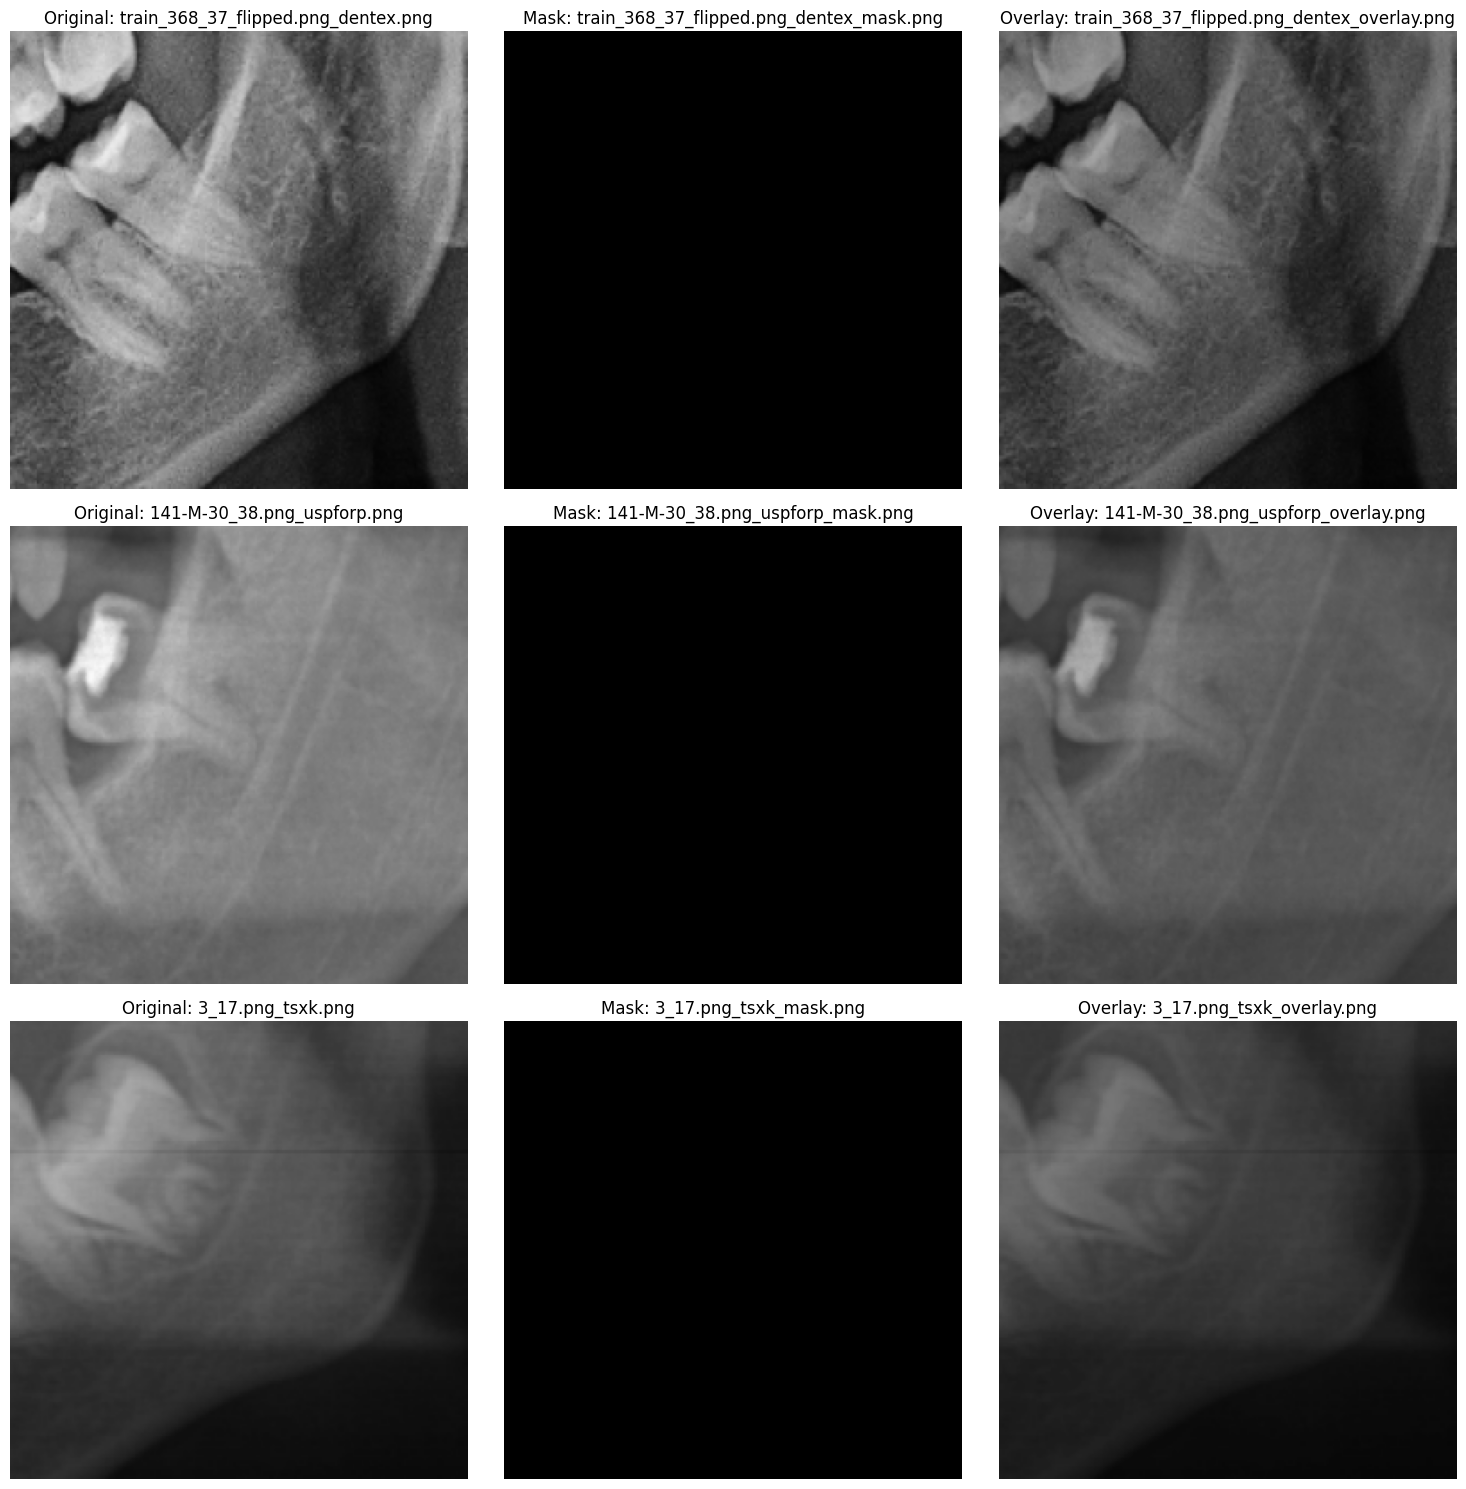

In [1]:
# =============================================
# Model Inference on Evaluation Datasets
# =============================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
import shutil
from tqdm import tqdm
import json

# Configuration
MODEL_PATH = "/home/sj/working_dir/adld_segmentation/yolo11_experiments/adld_seg_training_20250714_2227582/weights/best.pt"
INPUT_DIR = "/home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples"
OUTPUT_DIR = "/home/sj/working_dir/adld_segmentation/evaluate5datasets/all_5datasets_random50samples_segmented"

# Create output directories
output_dirs = {
    'originals': os.path.join(OUTPUT_DIR, 'originals'),
    'masks': os.path.join(OUTPUT_DIR, 'masks'),
    'overlayed': os.path.join(OUTPUT_DIR, 'overlayed')
}

for dir_path in output_dirs.values():
    os.makedirs(dir_path, exist_ok=True)

print("📁 Created output directories:")
for name, path in output_dirs.items():
    print(f"   {name}: {path}")

class ModelInference:
    """Class for performing inference with trained YOLOv11 segmentation model"""
    
    def __init__(self, model_path, confidence_threshold=0.25, iou_threshold=0.7):
        self.model_path = model_path
        self.confidence_threshold = confidence_threshold
        self.iou_threshold = iou_threshold
        self.model = None
        self.results_summary = []
        
    def load_model(self):
        """Load the trained model"""
        try:
            print(f"🤖 Loading model from: {self.model_path}")
            self.model = YOLO(self.model_path)
            print("✅ Model loaded successfully!")
            
            # Print model info
            try:
                model_info = self.model.info(verbose=False)
                print(f"📋 Model info: {model_info}")
            except:
                print("📋 Model loaded (info not available)")
                
        except Exception as e:
            print(f"❌ Error loading model: {e}")
            raise
    
    def create_segmentation_mask(self, result, img_shape):
        """Create segmentation mask from YOLO result"""
        mask = np.zeros(img_shape[:2], dtype=np.uint8)
        
        if result.masks is not None:
            for mask_data in result.masks.data:
                # Convert mask to numpy and resize to image shape
                mask_np = mask_data.cpu().numpy()
                mask_resized = cv2.resize(mask_np, (img_shape[1], img_shape[0]), interpolation=cv2.INTER_NEAREST)
                mask[mask_resized > 0.5] = 255
        
        return mask
    
    def create_overlay_image(self, original_img, mask, result):
        """Create overlay image with mask and annotations"""
        overlay = original_img.copy()
        
        # Create colored mask overlay
        colored_mask = np.zeros_like(original_img)
        colored_mask[mask > 0] = [0, 255, 0]  # Green color for teeth
        
        # Blend original image with colored mask
        overlay = cv2.addWeighted(original_img, 0.7, colored_mask, 0.3, 0)
        
        # Add contours
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (0, 0, 255), 2)  # Red contours
        
        # Add labels and confidence scores
        if result.boxes is not None:
            for i, box in enumerate(result.boxes):
                # Get confidence score
                confidence = float(box.conf.cpu().numpy()[0])
                
                # Get bounding box coordinates
                x1, y1, x2, y2 = box.xyxy.cpu().numpy()[0].astype(int)
                
                # Calculate center for text placement
                center_x = (x1 + x2) // 2
                center_y = (y1 + y2) // 2
                
                # Create label text
                label_text = f"Tooth: {confidence:.2f}"
                
                # Get text size for background rectangle
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.6
                thickness = 2
                text_size = cv2.getTextSize(label_text, font, font_scale, thickness)[0]
                
                # Draw background rectangle for better text visibility
                bg_x1 = center_x - text_size[0] // 2 - 5
                bg_y1 = center_y - text_size[1] - 10
                bg_x2 = center_x + text_size[0] // 2 + 5
                bg_y2 = center_y + 5
                
                cv2.rectangle(overlay, (bg_x1, bg_y1), (bg_x2, bg_y2), (0, 0, 0), -1)
                
                # Draw text
                text_x = center_x - text_size[0] // 2
                text_y = center_y - 5
                cv2.putText(overlay, label_text, (text_x, text_y), font, font_scale, (255, 255, 255), thickness)
                
                # Draw bounding box
                cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 0, 0), 2)
        
        return overlay
    
    def process_single_image(self, image_path, output_dirs):
        """Process a single image and save results"""
        try:
            # Load image
            image = cv2.imread(image_path)
            if image is None:
                print(f"⚠️ Could not load image: {image_path}")
                return None
            
            # Get image filename
            image_name = os.path.basename(image_path)
            name_without_ext = os.path.splitext(image_name)[0]
            
            # Run inference
            results = self.model.predict(
                image_path,
                conf=self.confidence_threshold,
                iou=self.iou_threshold,
                verbose=False
            )
            
            result = results[0]  # Get first result
            
            # Create segmentation mask
            mask = self.create_segmentation_mask(result, image.shape)
            
            # Create overlay image
            overlay = self.create_overlay_image(image, mask, result)
            
            # Save original image
            original_path = os.path.join(output_dirs['originals'], image_name)
            cv2.imwrite(original_path, image)
            
            # Save mask
            mask_path = os.path.join(output_dirs['masks'], f"{name_without_ext}_mask.png")
            cv2.imwrite(mask_path, mask)
            
            # Save overlay
            overlay_path = os.path.join(output_dirs['overlayed'], f"{name_without_ext}_overlay.png")
            cv2.imwrite(overlay_path, overlay)
            
            # Collect results summary
            num_detections = len(result.boxes) if result.boxes is not None else 0
            confidences = []
            if result.boxes is not None:
                confidences = [float(box.conf.cpu().numpy()[0]) for box in result.boxes]
            
            result_info = {
                'image_name': image_name,
                'num_detections': num_detections,
                'confidences': confidences,
                'avg_confidence': np.mean(confidences) if confidences else 0.0,
                'max_confidence': np.max(confidences) if confidences else 0.0,
                'has_segmentation': mask.sum() > 0
            }
            
            self.results_summary.append(result_info)
            
            return result_info
            
        except Exception as e:
            print(f"❌ Error processing {image_path}: {e}")
            return None
    
    def process_all_images(self, input_dir, output_dirs):
        """Process all images in the input directory"""
        # Get all image files
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']
        image_files = []
        
        for ext in image_extensions:
            image_files.extend(Path(input_dir).glob(f"*{ext}"))
            image_files.extend(Path(input_dir).glob(f"*{ext.upper()}"))
        
        print(f"📊 Found {len(image_files)} images to process")
        
        if len(image_files) == 0:
            print("⚠️ No images found in the input directory")
            return
        
        # Process images with progress bar
        successful_count = 0
        failed_count = 0
        
        for image_path in tqdm(image_files, desc="Processing images"):
            result = self.process_single_image(str(image_path), output_dirs)
            if result is not None:
                successful_count += 1
            else:
                failed_count += 1
        
        print(f"\n✅ Processing complete!")
        print(f"   Successful: {successful_count}")
        print(f"   Failed: {failed_count}")
        print(f"   Total: {len(image_files)}")
        
        return successful_count, failed_count
    
    def convert_numpy_types(self, obj):
        """Recursively convert numpy types to Python native types for JSON serialization"""
        if isinstance(obj, dict):
            return {key: self.convert_numpy_types(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [self.convert_numpy_types(item) for item in obj]
        elif hasattr(obj, 'item'):  # numpy scalar
            return obj.item()
        elif hasattr(obj, 'tolist'):  # numpy array
            return obj.tolist()
        else:
            return obj
    
    def save_results_summary(self, output_dir):
        """Save processing results summary"""
        summary_file = os.path.join(output_dir, "inference_summary.json")
        
        # Calculate overall statistics
        total_images = len(self.results_summary)
        images_with_detections = sum(1 for r in self.results_summary if r['num_detections'] > 0)
        images_with_segmentation = sum(1 for r in self.results_summary if r['has_segmentation'])
        
        all_confidences = []
        for r in self.results_summary:
            all_confidences.extend(r['confidences'])
        
        overall_stats = {
            'total_images_processed': int(total_images),
            'images_with_detections': int(images_with_detections),
            'images_with_segmentation': int(images_with_segmentation),
            'detection_rate': float(images_with_detections / total_images if total_images > 0 else 0),
            'segmentation_rate': float(images_with_segmentation / total_images if total_images > 0 else 0),
            'total_detections': int(len(all_confidences)),
            'average_confidence': float(np.mean(all_confidences) if all_confidences else 0),
            'confidence_std': float(np.std(all_confidences) if all_confidences else 0),
            'min_confidence': float(np.min(all_confidences) if all_confidences else 0),
            'max_confidence': float(np.max(all_confidences) if all_confidences else 0)
        }
        
        summary_data = {
            'model_path': str(self.model_path),
            'confidence_threshold': float(self.confidence_threshold),
            'iou_threshold': float(self.iou_threshold),
            'overall_statistics': overall_stats,
            'per_image_results': self.convert_numpy_types(self.results_summary)
        }
        
        with open(summary_file, 'w') as f:
            json.dump(summary_data, f, indent=2)
        
        print(f"📄 Results summary saved to: {summary_file}")
        
        # Print summary to console
        print(f"\n📊 Inference Summary:")
        print(f"   Total images: {total_images}")
        print(f"   Images with detections: {images_with_detections} ({overall_stats['detection_rate']:.1%})")
        print(f"   Images with segmentation: {images_with_segmentation} ({overall_stats['segmentation_rate']:.1%})")
        print(f"   Total detections: {len(all_confidences)}")
        if all_confidences:
            print(f"   Average confidence: {overall_stats['average_confidence']:.3f}")
            print(f"   Confidence range: {overall_stats['min_confidence']:.3f} - {overall_stats['max_confidence']:.3f}")
        
        return summary_data

# Initialize and run inference
print("🚀 Starting model inference on evaluation dataset")
print("=" * 60)

# Check if model exists
if not os.path.exists(MODEL_PATH):
    print(f"❌ Model not found at: {MODEL_PATH}")
    print("Please check the model path and try again.")
else:
    # Initialize inference engine
    inferencer = ModelInference(
        model_path=MODEL_PATH,
        confidence_threshold=0.25,  # Adjust as needed
        iou_threshold=0.7
    )
    
    # Load model
    inferencer.load_model()
    
    # Process all images
    success_count, fail_count = inferencer.process_all_images(INPUT_DIR, output_dirs)
    
    # Save results summary
    summary_data = inferencer.save_results_summary(OUTPUT_DIR)
    
    print("\n" + "=" * 60)
    print("🎉 INFERENCE COMPLETED SUCCESSFULLY!")
    print("=" * 60)
    print(f"📁 Results saved to: {OUTPUT_DIR}")
    print(f"   📷 Originals: {output_dirs['originals']}")
    print(f"   🎭 Masks: {output_dirs['masks']}")
    print(f"   🔗 Overlayed: {output_dirs['overlayed']}")
    print("=" * 60)

# Display some sample results
def display_sample_results(output_dirs, num_samples=3):
    """Display sample results from inference"""
    print(f"\n🖼️ Displaying {num_samples} sample results:")
    
    # Get sample files
    original_files = [f for f in os.listdir(output_dirs['originals']) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample_files = original_files[:num_samples]
    
    if not sample_files:
        print("⚠️ No sample files found")
        return
    
    fig, axes = plt.subplots(len(sample_files), 3, figsize=(15, 5 * len(sample_files)))
    if len(sample_files) == 1:
        axes = axes.reshape(1, -1)
    
    for i, filename in enumerate(sample_files):
        name_without_ext = os.path.splitext(filename)[0]
        
        # Load images
        original = cv2.imread(os.path.join(output_dirs['originals'], filename))
        mask = cv2.imread(os.path.join(output_dirs['masks'], f"{name_without_ext}_mask.png"), cv2.IMREAD_GRAYSCALE)
        overlay = cv2.imread(os.path.join(output_dirs['overlayed'], f"{name_without_ext}_overlay.png"))
        
        # Convert BGR to RGB for matplotlib
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
        
        # Display images
        axes[i, 0].imshow(original_rgb)
        axes[i, 0].set_title(f"Original: {filename}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title(f"Mask: {name_without_ext}_mask.png")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(overlay_rgb)
        axes[i, 2].set_title(f"Overlay: {name_without_ext}_overlay.png")
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display sample results
if 'inferencer' in locals() and inferencer.results_summary:
    display_sample_results(output_dirs, num_samples=3)
else:
    print("⚠️ No results to display")

In [ ]:
# =============================================
# VALIDATION SET EVALUATION WITH COMPARISONS
# =============================================

import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import json
from tqdm import tqdm

class ValidationEvaluator:
    """Evaluate trained model on validation set with ground truth comparisons"""
    
    def __init__(self, model_path, val_images_dir, val_labels_dir, output_dir, confidence_threshold=0.5):
        self.model_path = model_path
        self.val_images_dir = val_images_dir
        self.val_labels_dir = val_labels_dir
        self.output_dir = output_dir
        self.confidence_threshold = confidence_threshold
        self.iou_threshold = 0.7
        self.model = None
        self.results_summary = []
        
    def load_model(self):
        """Load the trained YOLO model"""
        print(f"🔄 Loading model from: {self.model_path}")
        try:
            self.model = YOLO(self.model_path)
            print("✅ Model loaded successfully!")
            return True
        except Exception as e:
            print(f"❌ Failed to load model: {e}")
            return False
    
    def setup_output_directories(self):
        """Create output directory structure"""
        dirs = {
            'originals': os.path.join(self.output_dir, 'originals'),
            'masks': os.path.join(self.output_dir, 'masks'),
            'overlayed': os.path.join(self.output_dir, 'overlayed'),
            'comparisons': os.path.join(self.output_dir, 'comparisons'),
            'ground_truth_masks': os.path.join(self.output_dir, 'ground_truth_masks'),
            'ground_truth_overlayed': os.path.join(self.output_dir, 'ground_truth_overlayed')
        }
        
        for dir_name, dir_path in dirs.items():
            os.makedirs(dir_path, exist_ok=True)
            print(f"📁 Created directory: {dir_path}")
        
        return dirs
    
    def parse_yolo_label(self, label_file, image_shape):
        """Parse YOLO format label file and create mask"""
        height, width = image_shape[:2]
        mask = np.zeros((height, width), dtype=np.uint8)
        
        if not os.path.exists(label_file):
            return mask, []
        
        annotations = []
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 6:  # Need at least class + 2 points for segmentation
                    continue
                
                class_id = int(parts[0])
                coords = list(map(float, parts[1:]))
                
                # Convert normalized coordinates to pixel coordinates
                points = []
                for i in range(0, len(coords), 2):
                    x = int(coords[i] * width)
                    y = int(coords[i + 1] * height)
                    points.append([x, y])
                
                if len(points) >= 3:  # Need at least 3 points for a polygon
                    # Fill polygon in mask
                    cv2.fillPoly(mask, [np.array(points)], 255)
                    annotations.append({
                        'class_id': class_id,
                        'points': points
                    })
        
        return mask, annotations
    
    def create_prediction_mask(self, result, image_shape):
        """Create mask from YOLO prediction result"""
        height, width = image_shape[:2]
        mask = np.zeros((height, width), dtype=np.uint8)
        
        if result.masks is not None:
            for mask_data in result.masks.data:
                # Convert mask to numpy and resize to image dimensions
                mask_np = mask_data.cpu().numpy()
                mask_resized = cv2.resize(mask_np, (width, height), interpolation=cv2.INTER_NEAREST)
                mask_binary = (mask_resized > 0.5).astype(np.uint8) * 255
                mask = cv2.bitwise_or(mask, mask_binary)
        
        return mask
    
    def create_overlay_image(self, image, mask, color=(0, 255, 0), alpha=0.6):
        """Create overlay image with colored mask"""
        overlay = image.copy()
        
        # Create colored mask
        colored_mask = np.zeros_like(image)
        colored_mask[mask > 0] = color
        
        # Blend images
        result = cv2.addWeighted(overlay, 1 - alpha, colored_mask, alpha, 0)
        return result
    
    def create_comparison_image(self, original_image, gt_mask, pred_mask, image_name, confidences=None):
        """Create side-by-side comparison image"""
        # Create overlays
        gt_overlay = self.create_overlay_image(original_image, gt_mask, color=(0, 255, 0), alpha=0.5)  # Green for GT
        pred_overlay = self.create_overlay_image(original_image, pred_mask, color=(0, 0, 255), alpha=0.5)  # Red for prediction
        
        # Add text labels
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        thickness = 1
        
        # Ground truth label
        cv2.putText(gt_overlay, "Ground Truth", (10, 30), font, font_scale, (255, 255, 255), thickness)
        
        # Prediction label with confidence if available
        pred_text = "Prediction"
        if confidences:
            avg_conf = np.mean(confidences)
            pred_text += f" (Conf: {avg_conf:.2f})"
        cv2.putText(pred_overlay, pred_text, (10, 30), font, font_scale, (255, 255, 255), thickness)
        
        # Combine images side by side
        comparison = np.hstack([gt_overlay, pred_overlay])
        return comparison
    
    def calculate_metrics(self, gt_mask, pred_mask):
        """Calculate segmentation metrics"""
        gt_binary = (gt_mask > 0).astype(np.uint8)
        pred_binary = (pred_mask > 0).astype(np.uint8)
        
        # Intersection and Union
        intersection = np.logical_and(gt_binary, pred_binary).sum()
        union = np.logical_or(gt_binary, pred_binary).sum()
        
        # IoU (Jaccard Index)
        iou = intersection / union if union > 0 else 0.0
        
        # Dice Coefficient
        dice = 2 * intersection / (gt_binary.sum() + pred_binary.sum()) if (gt_binary.sum() + pred_binary.sum()) > 0 else 0.0
        
        # Pixel Accuracy
        correct_pixels = np.logical_not(np.logical_xor(gt_binary, pred_binary)).sum()
        total_pixels = gt_binary.size
        pixel_accuracy = correct_pixels / total_pixels
        
        return {
            'iou': float(iou),
            'dice': float(dice),
            'pixel_accuracy': float(pixel_accuracy),
            'intersection': int(intersection),
            'union': int(union),
            'gt_area': int(gt_binary.sum()),
            'pred_area': int(pred_binary.sum())
        }
    
    def process_validation_image(self, image_path, output_dirs):
        """Process a single validation image"""
        try:
            # Load image
            image = cv2.imread(image_path)
            if image is None:
                print(f"⚠️ Could not load image: {image_path}")
                return None
            
            # Get corresponding label file
            image_name = os.path.basename(image_path)
            name_without_ext = os.path.splitext(image_name)[0]
            label_file = os.path.join(self.val_labels_dir, f"{name_without_ext}.txt")
            
            # Parse ground truth
            gt_mask, gt_annotations = self.parse_yolo_label(label_file, image.shape)
            
            # Run prediction
            results = self.model.predict(
                image_path,
                conf=self.confidence_threshold,
                iou=self.iou_threshold,
                verbose=False
            )
            
            result = results[0]
            pred_mask = self.create_prediction_mask(result, image.shape)
            
            # Calculate metrics
            metrics = self.calculate_metrics(gt_mask, pred_mask)
            
            # Get prediction confidences
            confidences = []
            if result.boxes is not None:
                confidences = [float(box.conf.cpu().numpy()[0]) for box in result.boxes]
            
            # Save original image
            cv2.imwrite(os.path.join(output_dirs['originals'], image_name), image)
            
            # Save predicted mask
            cv2.imwrite(os.path.join(output_dirs['masks'], f"{name_without_ext}_pred_mask.png"), pred_mask)
            
            # Save ground truth mask
            cv2.imwrite(os.path.join(output_dirs['ground_truth_masks'], f"{name_without_ext}_gt_mask.png"), gt_mask)
            
            # Save predicted overlay
            pred_overlay = self.create_overlay_image(image, pred_mask, color=(0, 0, 255), alpha=0.25)
            cv2.imwrite(os.path.join(output_dirs['overlayed'], f"{name_without_ext}_pred_overlay.png"), pred_overlay)
            
            # Save ground truth overlay
            gt_overlay = self.create_overlay_image(image, gt_mask, color=(0, 255, 0), alpha=0.25)
            cv2.imwrite(os.path.join(output_dirs['ground_truth_overlayed'], f"{name_without_ext}_gt_overlay.png"), gt_overlay)
            
            # Save comparison image
            comparison = self.create_comparison_image(image, gt_mask, pred_mask, image_name, confidences)
            cv2.imwrite(os.path.join(output_dirs['comparisons'], f"{name_without_ext}_comparison.png"), comparison)
            
            # Collect results
            result_info = {
                'image_name': image_name,
                'num_gt_annotations': len(gt_annotations),
                'num_predictions': len(result.boxes) if result.boxes is not None else 0,
                'confidences': confidences,
                'avg_confidence': float(np.mean(confidences)) if confidences else 0.0,
                'metrics': metrics,
                'has_gt_mask': gt_mask.sum() > 0,
                'has_pred_mask': pred_mask.sum() > 0
            }
            
            self.results_summary.append(result_info)
            return result_info
            
        except Exception as e:
            print(f"❌ Error processing {image_path}: {e}")
            return None
    
    def run_evaluation(self):
        """Run complete validation evaluation"""
        print("🚀 Starting validation set evaluation...")
        
        # Load model
        if not self.load_model():
            return False
        
        # Setup directories
        output_dirs = self.setup_output_directories()
        
        # Get all validation images
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']
        image_files = []
        
        for ext in image_extensions:
            image_files.extend(Path(self.val_images_dir).glob(f"*{ext}"))
            image_files.extend(Path(self.val_images_dir).glob(f"*{ext.upper()}"))
        
        print(f"📊 Found {len(image_files)} validation images")
        
        if len(image_files) == 0:
            print("⚠️ No validation images found!")
            return False
        
        # Process all images
        successful_count = 0
        failed_count = 0
        
        for image_path in tqdm(image_files, desc="Processing validation images"):
            result = self.process_validation_image(str(image_path), output_dirs)
            if result is not None:
                successful_count += 1
            else:
                failed_count += 1
        
        print(f"\n✅ Validation evaluation complete!")
        print(f"   Successful: {successful_count}")
        print(f"   Failed: {failed_count}")
        print(f"   Total: {len(image_files)}")
        
        # Save summary
        self.save_evaluation_summary(output_dirs)
        
        return True
    
    def convert_numpy_types(self, obj):
        """Recursively convert numpy types to Python native types for JSON serialization"""
        if isinstance(obj, dict):
            return {key: self.convert_numpy_types(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [self.convert_numpy_types(item) for item in obj]
        elif hasattr(obj, 'item'):  # numpy scalar
            return obj.item()
        elif hasattr(obj, 'tolist'):  # numpy array
            return obj.tolist()
        else:
            return obj
    
    def save_evaluation_summary(self, output_dirs):
        """Save comprehensive evaluation summary"""
        summary_file = os.path.join(self.output_dir, "validation_evaluation_summary.json")
        
        # Calculate overall metrics
        all_ious = [r['metrics']['iou'] for r in self.results_summary if r['metrics']['iou'] > 0]
        all_dice = [r['metrics']['dice'] for r in self.results_summary if r['metrics']['dice'] > 0]
        all_pixel_acc = [r['metrics']['pixel_accuracy'] for r in self.results_summary]
        all_confidences = []
        for r in self.results_summary:
            all_confidences.extend(r['confidences'])
        
        overall_stats = {
            'total_images': int(len(self.results_summary)),
            'images_with_gt': int(sum(1 for r in self.results_summary if r['has_gt_mask'])),
            'images_with_predictions': int(sum(1 for r in self.results_summary if r['has_pred_mask'])),
            'mean_iou': float(np.mean(all_ious)) if all_ious else 0.0,
            'std_iou': float(np.std(all_ious)) if all_ious else 0.0,
            'mean_dice': float(np.mean(all_dice)) if all_dice else 0.0,
            'std_dice': float(np.std(all_dice)) if all_dice else 0.0,
            'mean_pixel_accuracy': float(np.mean(all_pixel_acc)) if all_pixel_acc else 0.0,
            'mean_confidence': float(np.mean(all_confidences)) if all_confidences else 0.0,
            'total_predictions': int(len(all_confidences))
        }
        
        summary_data = {
            'model_path': str(self.model_path),
            'validation_images_dir': str(self.val_images_dir),
            'validation_labels_dir': str(self.val_labels_dir),
            'confidence_threshold': float(self.confidence_threshold),
            'iou_threshold': float(self.iou_threshold),
            'overall_statistics': overall_stats,
            'per_image_results': self.convert_numpy_types(self.results_summary)
        }
        
        with open(summary_file, 'w') as f:
            json.dump(summary_data, f, indent=2)
        
        print(f"📄 Evaluation summary saved to: {summary_file}")
        
        # Print summary to console
        print(f"\n📊 Validation Evaluation Summary:")
        print(f"   Total images: {overall_stats['total_images']}")
        print(f"   Images with GT masks: {overall_stats['images_with_gt']}")
        print(f"   Images with predictions: {overall_stats['images_with_predictions']}")
        print(f"   Mean IoU: {overall_stats['mean_iou']:.3f} ± {overall_stats['std_iou']:.3f}")
        print(f"   Mean Dice: {overall_stats['mean_dice']:.3f} ± {overall_stats['std_dice']:.3f}")
        print(f"   Mean Pixel Accuracy: {overall_stats['mean_pixel_accuracy']:.3f}")
        print(f"   Mean Confidence: {overall_stats['mean_confidence']:.3f}")
        print(f"   Total predictions: {overall_stats['total_predictions']}")
        
        return summary_data

# Display sample comparison results
def display_validation_samples(output_dir, num_samples=3):
    """Display sample validation comparison results"""
    comparisons_dir = os.path.join(output_dir, 'comparisons')
    
    if not os.path.exists(comparisons_dir):
        print("⚠️ No comparison images found")
        return
    
    # Get sample files
    comparison_files = [f for f in os.listdir(comparisons_dir) if f.endswith('.png')]
    sample_files = comparison_files[:num_samples]
    
    if not sample_files:
        print("⚠️ No comparison files found")
        return
    
    print(f"\n🖼️ Displaying {len(sample_files)} validation comparison samples:")
    
    fig, axes = plt.subplots(len(sample_files), 1, figsize=(16, 6 * len(sample_files)))
    if len(sample_files) == 1:
        axes = [axes]
    
    for i, filename in enumerate(sample_files):
        comparison_path = os.path.join(comparisons_dir, filename)
        comparison_img = cv2.imread(comparison_path)
        comparison_rgb = cv2.cvtColor(comparison_img, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(comparison_rgb)
        axes[i].set_title(f"Validation Comparison: {filename}", fontsize=14)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("🔧 ValidationEvaluator class ready for use!")
print("📋 Next: Run the evaluation on your validation set")

In [ ]:
# =============================================
# RUN VALIDATION EVALUATION
# =============================================

# Define paths
VAL_IMAGES_DIR = "/home/sj/working_dir/adld_segmentation/adld_yolo/images/val"
VAL_LABELS_DIR = "/home/sj/working_dir/adld_segmentation/adld_yolo/labels/val"
VAL_OUTPUT_DIR = "/home/sj/working_dir/adld_segmentation/adld_yolo/images/val_segmented"
CORRECT_MODEL_PATH = "/home/sj/working_dir/adld_segmentation/yolo11_experiments/adld_seg_training_20250714_2201362/weights/best.pt"
# Verify paths exist
print("🔍 Verifying input paths...")
if os.path.exists(VAL_IMAGES_DIR):
    val_image_count = len([f for f in os.listdir(VAL_IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])
    print(f"✅ Validation images directory: {val_image_count} images found")
else:
    print(f"❌ Validation images directory not found: {VAL_IMAGES_DIR}")

if os.path.exists(VAL_LABELS_DIR):
    val_label_count = len([f for f in os.listdir(VAL_LABELS_DIR) if f.endswith('.txt')])
    print(f"✅ Validation labels directory: {val_label_count} label files found")
else:
    print(f"❌ Validation labels directory not found: {VAL_LABELS_DIR}")

# Use the trained model (should be available from previous cells)
if 'CORRECT_MODEL_PATH' in locals() and CORRECT_MODEL_PATH and os.path.exists(CORRECT_MODEL_PATH):
    print(f"✅ Using model: {CORRECT_MODEL_PATH}")
    VALIDATION_MODEL_PATH = CORRECT_MODEL_PATH
elif 'MODEL_PATH' in locals() and MODEL_PATH and os.path.exists(MODEL_PATH):
    print(f"✅ Using model: {MODEL_PATH}")
    VALIDATION_MODEL_PATH = MODEL_PATH
else:
    # Try to find model automatically
    base_dir = "/home/sj/working_dir/adld_segmentation/yolo11_experiments"
    VALIDATION_MODEL_PATH = None
    
    if os.path.exists(base_dir):
        experiment_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
        experiment_dirs.sort(reverse=True)  # Most recent first
        
        for exp_dir in experiment_dirs:
            best_model = os.path.join(base_dir, exp_dir, "weights", "best.pt")
            if os.path.exists(best_model):
                VALIDATION_MODEL_PATH = best_model
                print(f"✅ Found model: {VALIDATION_MODEL_PATH}")
                break
    
    if not VALIDATION_MODEL_PATH:
        print("❌ No trained model found! Please run training first.")

print("\n" + "="*60)

In [ ]:
# =============================================
# EXECUTE VALIDATION EVALUATION
# =============================================

if VALIDATION_MODEL_PATH and os.path.exists(VAL_IMAGES_DIR) and os.path.exists(VAL_LABELS_DIR):
    print("🚀 Starting validation evaluation...")
    
    # Initialize evaluator
    evaluator = ValidationEvaluator(
        model_path=VALIDATION_MODEL_PATH,
        val_images_dir=VAL_IMAGES_DIR,
        val_labels_dir=VAL_LABELS_DIR,
        output_dir=VAL_OUTPUT_DIR,
        confidence_threshold=0.5
    )
    
    # Run evaluation
    try:
        success = evaluator.run_evaluation()
        
        if success:
            print("\n✅ Validation evaluation completed successfully!")
            
            # Show summary
            print("\n📊 Results Summary:")
            print(f"   📁 Results saved to: {VAL_OUTPUT_DIR}")
            print(f"   📂 Original images: {VAL_OUTPUT_DIR}/originals")
            print(f"   🎭 Predicted masks: {VAL_OUTPUT_DIR}/masks")
            print(f"   🎯 Ground truth masks: {VAL_OUTPUT_DIR}/ground_truth_masks")
            print(f"   🖼️ Predicted overlays: {VAL_OUTPUT_DIR}/overlayed")
            print(f"   🌟 Ground truth overlays: {VAL_OUTPUT_DIR}/ground_truth_overlayed")
            print(f"   📊 Comparison images: {VAL_OUTPUT_DIR}/comparisons")
            print(f"   📋 Evaluation summary: {VAL_OUTPUT_DIR}/validation_evaluation_summary.json")
            
            # Display sample comparisons
            print("\n🖼️ Displaying sample comparison results:")
            display_validation_samples(VAL_OUTPUT_DIR, num_samples=3)
            
        else:
            print("❌ Validation evaluation failed!")
            
    except Exception as e:
        print(f"❌ Error during validation evaluation: {str(e)}")
        import traceback
        traceback.print_exc()
        
else:
    print("❌ Cannot run validation evaluation!")
    if not VALIDATION_MODEL_PATH:
        print("   - No trained model found")
    if not os.path.exists(VAL_IMAGES_DIR):
        print(f"   - Validation images directory not found: {VAL_IMAGES_DIR}")
    if not os.path.exists(VAL_LABELS_DIR):
        print(f"   - Validation labels directory not found: {VAL_LABELS_DIR}")
    print("\nPlease ensure all paths are correct and you have trained a model.")